In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:10pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:10pt;padding:5px;}
table.dataframe{font-size:15px;
</style>
"""))

**<font size="6" color="red">ch2. 한글 형태소 분석</font>**
# 1. 자연어처리
- 자연어 : 일상적인 언어
- 자연어 처리 분야:
    * 자연어 이해 : 형태소분석 -> postagging -> 의미분석, 시각화
    * 자연어 생성 : RNN, LSTM, GRU, ... , encoder-decoder알고리즘 -> 트랜스포머알고리즘
- 활용분야 : 트랜드분석, 탐색적 분석, 맞춤법검사, 번역기, 쳇봇

# 2. 자연어 이해 처리 절차
- 전처리 : 단어, 어절 추출
- 분석 후보 생성 : 형태소 분리, 품사태깅(pos tagging)
- 제약조건(불용어 처리) : 규칙 확인
- 분석 : 시각화(워드클라우드), 연관분석, RNN, LSTM, GRU, ...

# 3. 한글형태소 분석 엔진(Konlpy,...)
- 공통기능 : morphs(형태소 나누기), nouns(명사추출), pos(형태소로 나누어 품사 태그)

- Konlpy (pip install konlpy : jpype1라이브러를 의존)
    * HanNanum : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path설정)
    * Kkma     : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path설정)
    * Komoran  : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path설정)
    * Okt
- Mecab (pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양환경에서 사용 가능. 다국어 바인딩 지원

In [2]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [3]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

## 3.1 HanNanum

In [ ]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                   max_heap_size=512) # 기본값:1024, '10m', '1g', 최대사이즈 4Gb
hannanum.analyze(text) # ntag=69로 형태소 분석 후보 

- pos tagging chart 다운로드
    - 구글에서 konlpy docs 검색후 https://konlpy.org/
    - api 메뉴 -> "Comparison between POS tagging classes"클릭 -> Korean POS tags comparison chart클릭

In [ ]:
# 형태소 분석 :morphs
print(hannanum.morphs(text))

In [ ]:
# 명사만 추출
print(hannanum.nouns(text))

In [ ]:
# 품사태그
print(hannanum.pos(text)) # 품사갯수 기본값 ntags=9

In [ ]:
print(hannanum.pos(text, ntags=22))

In [ ]:
# 퀴즈 1: text에서 형용사(PA)만 추출

In [ ]:
tagged_text = hannanum.pos(text, ntags=22)
words = [token for token, tag in tagged_text if tag=='PA']

# for token, tag in tagged_text:
#     if tag == 'PA':
#         word.append(token)

words


In [ ]:
# 퀴즈 2 : text에서 명사만 추출(NC, NQ, NB, NN, NP)
print([token for token, tag in tagged_text if tag.find('N')!=-1]) # N 이없으면 가능
print([(token, tag) for token, tag in tagged_text if tag in ('NC','NQ','NB','NN','NP')])
print([hannanum.nouns(text)])


In [ ]:
# 퀴즈 3 : text에서 보통명사(NC)만 추출
[token for token, tag in tagged_text if tag=='NC']

## 3.2 Kkma

In [ ]:
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None,
            max_heap_size=1024) # "4m", "4g"
# 형태소 분석
print(kkma.morphs(text)) 

In [ ]:
# 명사추출
print(kkma.nouns(text)) 

In [ ]:
# 품사 태깅
print(kkma.pos(text)) # ntags 지정 불가(무조건 56으로)

In [ ]:
# 명사 추출
tagged_text = kkma.pos(text)
print([word for word, tag in tagged_text if tag in ('NNG','NNP','NNB','NNM') ])
print(kkma.nouns(text))

In [ ]:
# 보통명사(NNG) + 고유명사(MNP)
print([word for word, tag in tagged_text if tag in ('NNG','NNP')])

## 3.3 Komoran

In [ ]:
from konlpy.tag import Komoran
komoran = Komoran() # max_heap_size=1-24
# 형태소 분석
print(komoran.morphs(text))

In [ ]:
# 명사추출 
print(komoran.nouns(text))

In [ ]:
# 품사태깅
print(komoran.pos(text)) # ntags 조정 불가


In [ ]:
# 일반명사, 고유명사만 추출
[token for token in komoran.pos(text) if tag in ('')]

## 3.4 Twitter(Okt:Open Korean Text)
- konlpy v0.4.5부터 Twitter -> Okt로 바뀜


In [ ]:
import konlpy
konlpy.__version__

In [ ]:
from konlpy.tag import Twitter, Okt
# okt = Twitter()
okt = Okt() # max_heap_size
print('구 추출 :', okt.phrases(text))
print('형태소 추출 :', okt.morphs(text))
print('명사 추출 :', okt.nouns(text))
tagged_text = okt.pos(text)
print('품사 태깅을 이용한 명사 추출 :',
     [token for token, tag in tagged_text if tag=='Noun']
     )
print('품사 태깅 :', okt.pos(text))


## 3.5 MeCab
- pip install python-mecab-ko

In [ ]:
%%time
from mecab import MeCap
mecab = MeCab() # 힙메모리 사이즈 지정이 안됨
print('형태소 추출 :', mecab.morphs(text))
print('명사 추출 :', mecab.nouns(text))
tagged_text = mecap.pos(text) # ntags 조정 불가(ntags=43 고정)
print('품사 태깅을 이용한 명사 추출 :',
     [token for token, tag in tagged_text\
      if tag==('NNG','NNP','NNB','NNBC','NR','NP')]
     )
print('품사태깅 :'. tagged_text)

# 4. 말뭉치

In [4]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')

In [5]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [6]:
# 한글 말뭉치
from konlpy.corpus import kolaw
# data = kolaw.open('constitution.txt').readlines() # 한줄씩 list로 반환 
data = kolaw.open('constitution.txt').read()
print('글자수 :', len(data))
print('%r' % data[:100])


글자수 : 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의'


# 5. 워드 클라우드
- pip install wordcloud


In [7]:
# 말뭉치에서 단어 추출(특수 문자 제외)
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
# ret = RegexpTokenizer('[a-zA-Z0-9]')
# ret = RegexpTokenizer('[]')
ret = RegexpTokenizer('[\w]{2,}')
words = ret.tokenize(emma)
# 명사만 추출
emma_tags = pos_tag(words)
noun_list = [token for token, tag in emma_tags if tag in ('NN','NNS')]
# print(len(noun_list), len(set(noun_list)))
print('추출된 명사 갯수 :', len(noun_list), '\t단어종류수 :', len(set(noun_list)))
print('noun_list',noun_list[:10])
emma_noun = ' '.join(noun_list)
print('워드클라우드에 필요한 내용 :', emma_noun[:100])

추출된 명사 갯수 : 22362 	단어종류수 : 3498
noun_list ['Emma', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world', 'daughters', 'indulgent']
워드클라우드에 필요한 내용 : Emma clever home disposition blessings existence years world daughters indulgent father consequence 


In [9]:
l = ['aaa','bbb','ccc','aaa']
' '.join(l)

'aaa bbb ccc aaa'

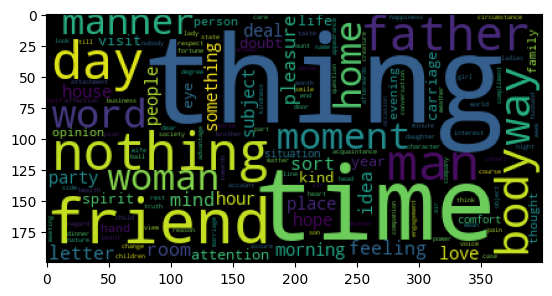

In [8]:
from wordcloud import WordCloud
# import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
wordc = WordCloud()
wordc.generate(emma_noun)
plt.imshow(wordc)
plt.show()

-  컬러맵 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

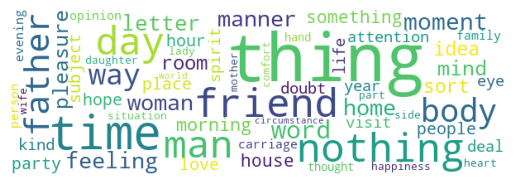

In [10]:
wordcloud = WordCloud(# font_path=''
                      width=600, # 생성될 이미지 가로(픽셀)
                      background_color='white', # 배경색
                      max_words=300, # 표시될 단어의 최대 갯수
                      relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                      colormap='viridis', # 글씨 칼라맵
                      max_font_size=80, # 최대 폰트 사이즈
                      min_font_size=10 # 최소 폰트 사이즈
)
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
# 한글 말뭉치 data로 워드클라우드 시각화
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab      import MeCab
analyzer = MeCab()
noun_list1 = analyzer.nouns(data)
noun_list2 = [word for word, tag in analyzer.pos(data) if tag in ('NNG','NNP')]
print(noun_list1[:20])
print(noun_list2[:20])

# MeCab 당첨!!



In [55]:
# 한글 말뭉치 data로 워드클라우드 시각화
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab      import MeCab
analyzer = MeCab()
noun_list2 = [word for word, tag in analyzer.pos(data)\
              if tag in ('NNG','NNP')]
data_noun = ' '.join(noun_list)

In [ ]:
# wordcloud = WordCloud(# font_path=''
# #                       width=800, # 생성될 이미지 가로(픽셀)
#                       background_color='white', # 배경색
#                       max_words=300, # 표시될 단어의 최대 갯수
#                       relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
#                       colormap='viridis', # 글씨 칼라맵
#                       max_font_size=80, # 최대 폰트 사이즈
#                       min_font_size=10 # 최소 폰트 사이즈
# )
# wordcloud.generate(data_noun)
# plt.imshow(wordcloud)
# plt.axis('off')
# plt.show()

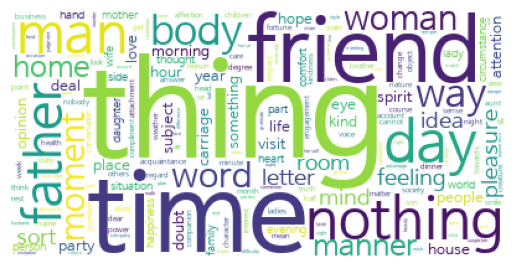

In [14]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3
                stopwords=불용어
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [13]:
# 불영어 처리(불용어 지정 + 불용어 사전)
from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'} # | : 집합합연산사
불용어 = {'대통령','법률'}
불용어 = set(['대통령','법률','조'])
불용어

{'대통령', '법률', '조'}

In [15]:
# 한글 말뭉치 data로 워드클라우드 시각화
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab      import MeCab
analyzer = MeCab()
noun_list = analyzer.nouns(data)
noun_list = [word for word, tag in analyzer.pos(data) \
              if tag in ('NNG', 'NNP')]
data_noun = ' '.join(noun_list)
data_noun[:100]

'대한민국 헌법 역사 전통 국민 운동 건립 대한민국 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 인도 동포 애 민족 단결 사회 폐습 불의 타'

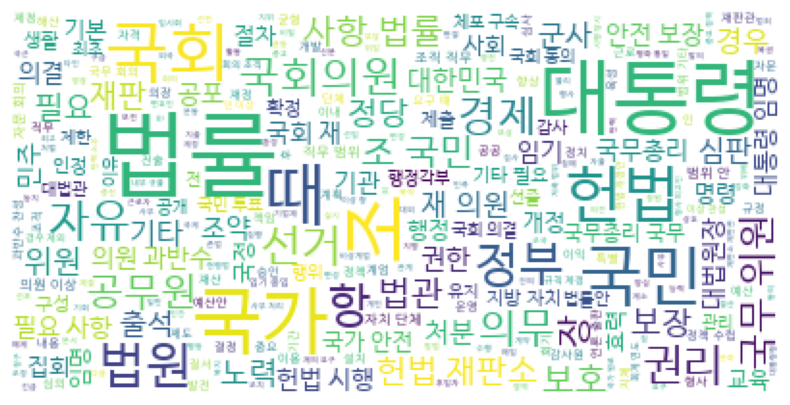

In [13]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

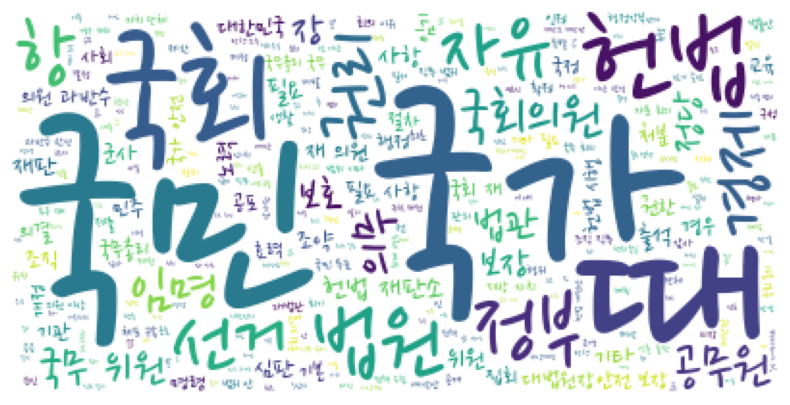

In [16]:
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [23]:
# 마스킹 :  워드클라우드를 지정된 마스크 이미지에 맞도록 설정
import cv2
# %pip show opencv-contrib-python


Name: opencv-contrib-python
Version: 4.11.0.86
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


(468, 720, 3)

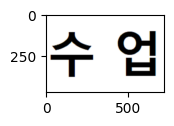

In [25]:
# 마스킹 : 워드클라우드를 지정된 마스크 이미지에 맞도록 설정
# 이미지를 넘파이 배열로 방법1
from PIL import Image
import numpy as np
img = Image.open('data/test.png')
mask = np.array(img)
plt.figure(figsize=(2,1))
plt.imshow(mask)
mask.shape

(468, 720, 3)

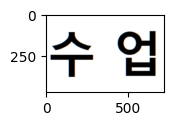

In [26]:
# 이미지를 넘파이 배열로 방법2
import cv2
# %pip install opencv-contrib-python
mask = cv2.imread('data/test.png'
                 # , cv2.IMREAD_GRAYSCALE
                 )
plt.figure(figsize=(2,1))
plt.imshow(mask)
mask.shape

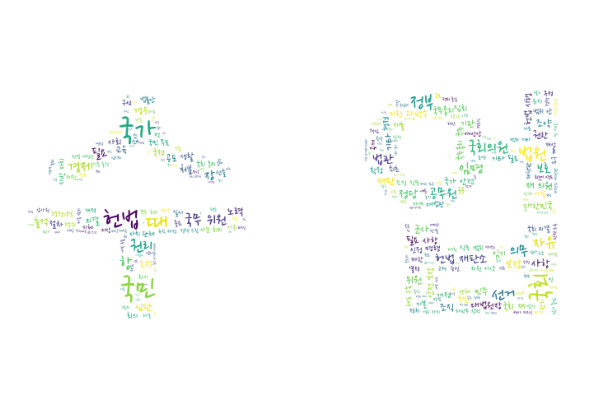

In [27]:
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

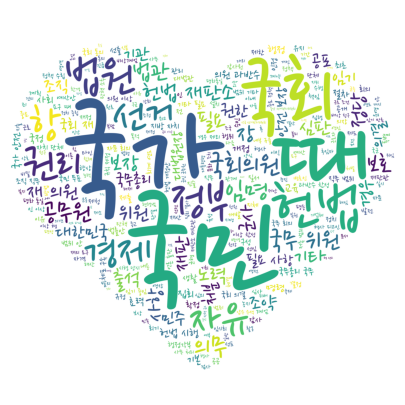

In [28]:
mask2 = cv2.imread('data/heart.jpg')
# plt.figure(figsize=(2,2))
# plt.imshow(mask2)
# mask2.shape
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask2
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

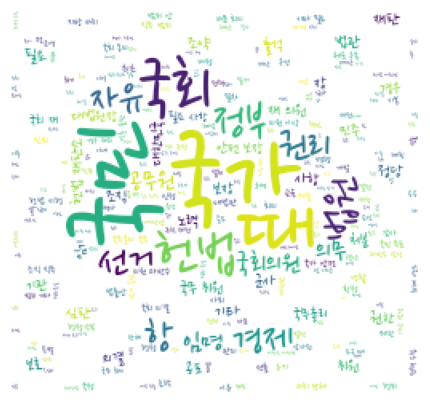

In [30]:
mask3 = cv2.imread('data/test2.jpg')
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask3
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

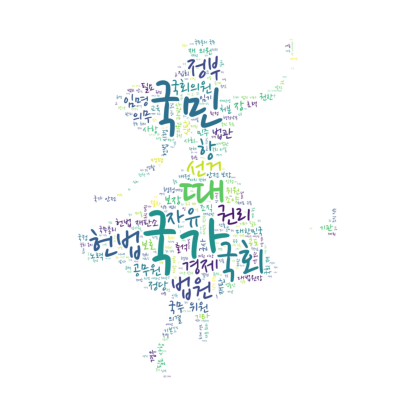

In [32]:
mask4 = cv2.imread('data/test3.png')
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask4
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


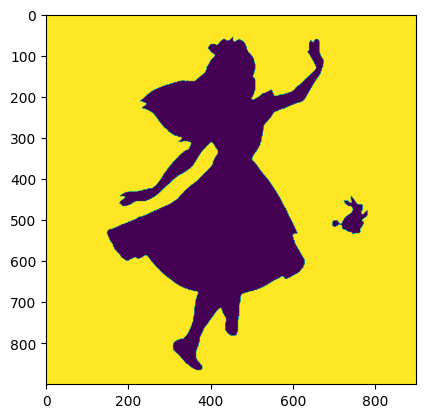

In [44]:
# mask5 = cv2.imread('data/south_korea.png')
img = Image.open('data/test3.png')
mask5 = np.array(img)
plt.imshow(mask5)


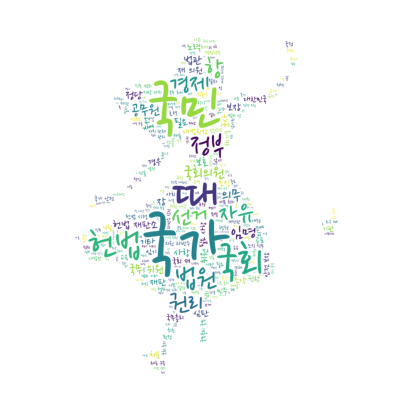

In [45]:
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask5
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(1124, 720)


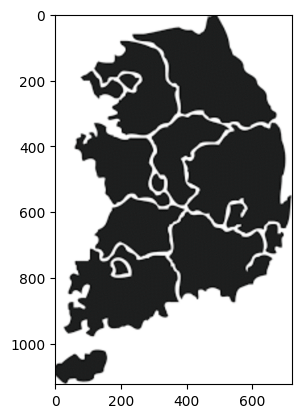

In [48]:
# convert('RGB') : 1채널 이미지파일 -> 3채널
# convert('RGBA') : 1채널 이미지파일 -> 4채널(RGB+ 투명도채널)
img = Image.open('data/south_korea.png').convert('RGB')
mask5 = np.array(img)
print(mast5.shape)
plt.imshow(mask5)

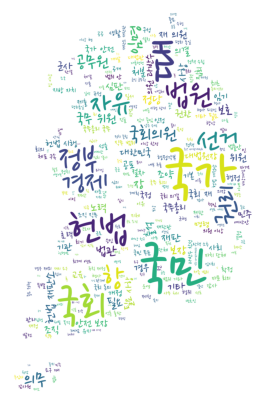

In [49]:
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask5
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

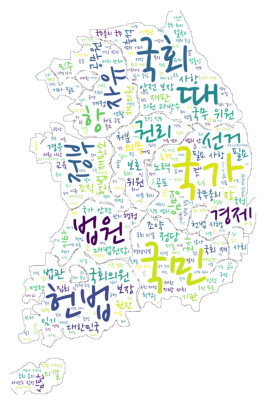

In [51]:
# 지도에서 각 도별 경계선을 명확히 보고싶다.
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask5,
                contour_color='gray', # 이 부분을 추가
                contour_width=1 # 이 부분을 추가
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [53]:
# 생성된 wordcloud 저장
wordcloud.to_file('korea.jpg') # jpg / png 포맷 가능

## 단어의 빈도수 시각화(nltk.Text)

In [ ]:
불용어 = {'법률','대통령'}
noun_process = [word for word in noun_list if word not in 불용어]

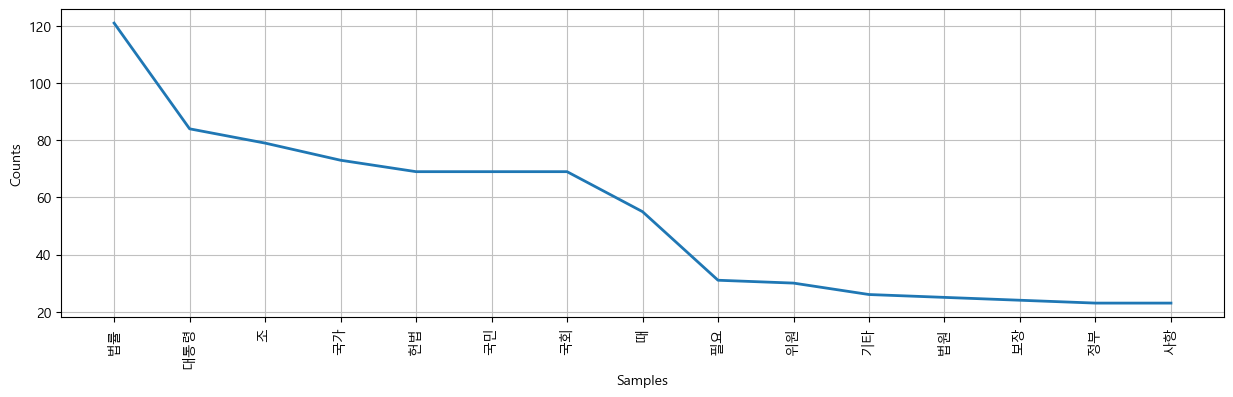

In [63]:
import nltk
data_text = nltk.Text(noun_list)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()

In [66]:
data_text.vocab().most_common(15) # 정확한 숫자를 알고 싶을 때

[('법률', 121),
 ('대통령', 84),
 ('조', 79),
 ('국가', 73),
 ('헌법', 69),
 ('국민', 69),
 ('국회', 69),
 ('때', 55),
 ('필요', 31),
 ('위원', 30),
 ('기타', 26),
 ('법원', 25),
 ('보장', 24),
 ('정부', 23),
 ('사항', 23)]

('법률', '대통령', '조', '국가', '헌법', '국민', '국회', '때', '필요', '위원', '기타', '법원', '보장', '정부', '사항')
(121, 84, 79, 73, 69, 69, 69, 55, 31, 30, 26, 25, 24, 23, 23)


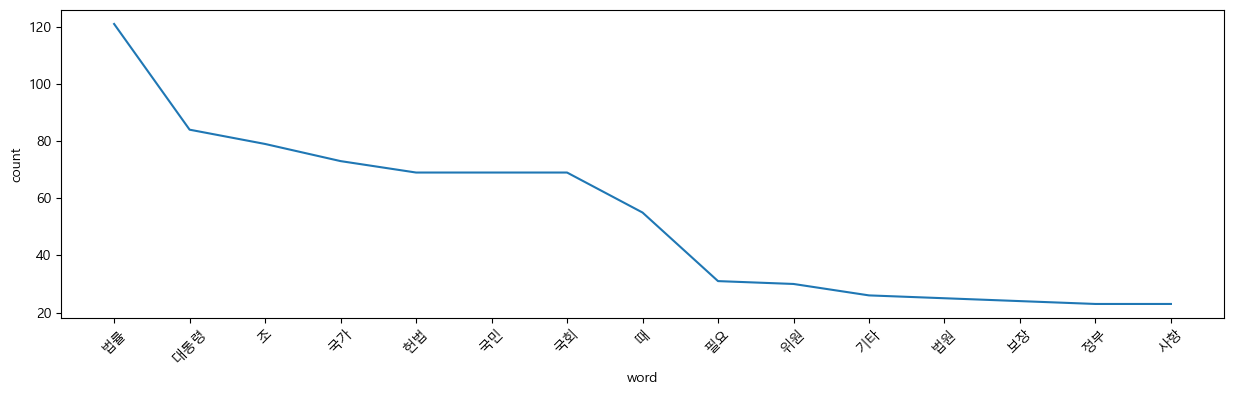

In [76]:
word, counts = zip(*data_text.vocab().most_common(15))
print(word)
print(counts)
plt.figure(figsize=(15,4))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.show()

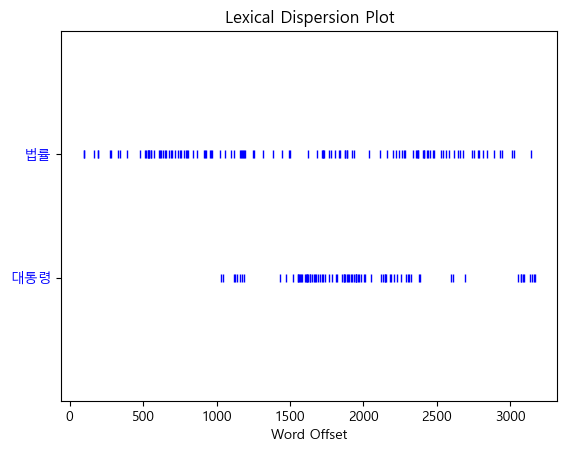

In [77]:
data_text.dispersion_plot(['법률','대통령'])

# 6. 워드 임베딩
- 단어간 벡터 계산 -> 단어간 유사성 도출


In [84]:
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response =  requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, "xml")
link_el = soup.select('item link')
link_list = [el.text for el in link_el]
print(len(link_list), link_list)

20 ['https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220943', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220949', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220832', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220765', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220766', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220665', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220651', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220627', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220516', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220366', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220365', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220169', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220180', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12219888', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12

In [100]:
''' 각 link 들의 뉴스 기사 -> 명사만 : 
    [['등촌','재건축','명사1', ......],
    ['캠핑장','재건축','명사2', ......], .....]
'''
from konlpy.tag import Kkma
kkma = Kkma()
news = []
for link in link_list:
#     print(link, '에 가서 기사(title, desc)를 가져온다')
    response = requests.get(link)
#    print(response.status_code) 상태 확인
    news_soup = BeautifulSoup(response.content, "html.parser")
    title = news_soup.select_one('title').text
    description = str(news_soup.select_one('meta[name="description"]'))
#     print(title + ' ' + description)
    noun_list = kkma.nouns(title + ' ' + description)
    불용어 = {'뉴스','앵커'}
    noun_list = [word for word in noun_list if word not in 불용어]
#     print(noun_list)
    news.append(noun_list)

['촌', '촌주공', '주공', '전', '홍수', '예상', '눈치', '눈치게임', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '아파트', '입주', '다음', '말', '대규모', '전세', '전세매물', '매물', '현장']
['실제', '완전', '사기', '캠핑', '캠핑장', '장', '관리', '소홀', '예약', '때', '플랫폼', '사진', '기대', '당황', '분']
['요즘', '끼', '편의점', '정도', '정도일', '일', '줄', '2', '2만', '만', '원', '육박', '점심', '점심값', '값', '도시락', '때', '7000', '7000원', '식비', '부담']
['오늘', '겠다', '말', '이유', '편의점', '도시락', '7', '7천원', '천', '원', '시대', '주머니', '직장인', '자취생', '눈앞', '아람', '기자']
['경영권', '분쟁', '주', '표', '표대결', '대결', '로', '롤러', '롤러코스터', '코스터', '고려', '고려아연', '아연', '주가', '오늘', '28', '28일', '일', '장', '장중', '중', '15', '포인트', '말', '달', '이어진', '공개', '공개매수', '매수', '절차', '마무리', '뚜껑', '어보']
['결혼', '돈', '걱정', '예비', '예비부부', '부부', '저출산', '문제지', '현실', '결혼식', '비용', '문제', '소식', '정', '정아람', '아람', '기자', '전', '전해드', '해드']
['예비', '예비부부', '부부', '웨딩', '물가', '올해', '예식장', '비용', '21', '한편', '결혼식', '비싸져', '식', '소식', '정', '정아람', '아람', '기자', '내년', '5', '5월', '월', '결혼']
['20', '20대', '대', '정규직', '비중', '역대', '최고', '10', '

In [114]:
# rss의 title과 descrition => 명사 추출 => 워드임베딩(단어간 거리)
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jstc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, "xml")
news = []
item_elems = soup.find_all('item')
for item_elem in item_elems:
    title = item_elem.find('title').text
    description = item_elem.find('description').text
#     print(title + ' ' + description,)
    article = title + ' ' + description.replace('[앵커]',' ')
#     noun_list1 = kkma.nouns(article)
    # 보통명사(NNG), 고유명사(NNP)
    noun_list = [ word for word, tag in kkma.pos(article) if tag in ('NNG','NNP')]
#     print(noun_list1)
#     print(noun_list2, '\n\n')
    news.append(noun_list)
print(news[:3])

[['촌', '주공', '전', '홍수', '예상', '눈치', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '촌', '주공', '아파트', '입주', '다음', '말', '시작', '대규모', '입주', '전세', '매물', '현장', '분위기', '이'], ['실제', '완전', '사기', '캠핑', '장', '관리', '소홀', '캠핑', '장', '예약', '때', '예약', '플랫폼', '사진', '실제', '불만', '경우', '앞', '예약', '플랫폼', '책임', '강화', '아람', '기자', '기자', '인터넷', '카페'], ['요즘', '끼', '편의점', '정도', '일', '줄', '육박', '점심', '값', '편의점', '도시락', '끼', '때', '편의점', '도시락', '식비', '부담', '아람', '기자', '기자', '서울', '한']]


In [113]:
# 워드 임베딩 (단어간 거리 계산)
# pip install gensim
from gensim.models import Word2Vec
model = Word2Vec(news, # 학습데이터 2차원
                window=10, # 각 단어의 촤주 10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1  # 병렬처리 Core수. -1:모든 가용 Core 사용
                )


In [122]:
model.wv.most_similar('기자')

[('가격', 0.18890605866909027),
 ('전', 0.18855659663677216),
 ('코스터', 0.18359005451202393),
 ('예산', 0.18345923721790314),
 ('김', 0.17804878950119019),
 ('내년', 0.16072483360767365),
 ('직전', 0.15974178910255432),
 ('아파트', 0.15923379361629486),
 ('실제', 0.15861040353775024),
 ('어제', 0.15196380019187927)]

In [117]:
model.wv.most_similar('아파트', topn=3)

[('아연', 0.2122785449028015),
 ('불리', 0.19188855588436127),
 ('매출', 0.16693152487277985)]